## Image Representations

<h2><b>What is the meaning of 'representations of images'?</b></h2>

An image representation refers to the process of translating raw, high-dimensional visual data (like tens of thousands of RGB pixel values) into a compressed, abstract, or more useful mathematical form.
Fundamentally, image representation is rooted in dimensionality reduction. While raw image data $x$ exists in a massive, high-dimensional coordinate system, realistic images (like faces or natural scenes) only occupy a tiny subset or "manifold" of that space. Creating a representation means finding a "low-dimensional (or hidden) representation $h$, which can approximately explain the data $x$, so that $x \approx f[h,\theta]$".

<h3>What is achieved by image representation?</h3>

1. <i>Dimensionality reduction</i> : From thousands of rows of RGB values, we come down to few hundreds of rows of representation.
2. <i> A Compact Summary of Critical Information</i>: A representation serves as a "highly compact representation" that summarizes an image region while retaining the "critical information about the image appearance and layout".
3. <i> A Method to Filter Out Irrelevant Variations </i>: In real-world computer vision, raw RGB values constantly fluctuate due to factors that have nothing to do with the actual object, such as changes in ambient lighting, camera gain, or slight shifts in pose.
4. <i> An Intermediate Stepping Stone for Inference </i>: Representations act as an "intermediate representation for inferring higher-level properties".

<h2><b>The Dataset: ImageNet</b></h2>

**ImageNet** is a massive, foundational visual database designed specifically to support visual object recognition and computer vision research. It serves as a comprehensive "visual dictionary" for computers and has been instrumental in advancing deep learning models.

* **Scale and Scope:** The full dataset (sometimes referred to as ImageNet-21K) contains more than 14 million images that have been hand-annotated.
* **Organization:** It is structured according to the WordNet lexical hierarchy, where each node or concept (called a "synset") is depicted by hundreds or thousands of images. The full dataset contains over 20,000 distinct categories, ranging from specific dog breeds to everyday objects like balloons or strawberries.
* **Annotation:** The images were scraped from search engines and then rigorously human-annotated using Amazon's Mechanical Turk platform to verify the presence of specific objects. Over one million of these images also include object-level bounding boxes to show exactly where the object is located.

Working on entire ImageNet dataset is both laborious and unnecessary. Therefore, this study of creating representations is done on a subset of ImageNet. A 100,000 images were sampled at random from the dataset and were subsequently split into training, validation and test sets in the ratio of 8:1:1 respectively.

<h2><b>The Architecture: Convolutional Autoencoder</b></h2>

The ImageNet dataset is vast and it varies greatly. Hence the ideal architecture to encode the image is a **Convolutional Autoencoder** where stacks of <code>nn.Conv2d</code> and <code>nn.MaxPool2d</code> layers. Each step will increase the number of feature channels while slicing the spatial dimensions ($H \times W$) in half, squeezing the image down into your dense, low-dimensional latent representation.

The same network can later function as a decoder to extract images from the representations.

<h3><b>The Pipeline</b></h3>

* **1. Dataset:** 100k random ImageNet images, split 8:1:1 (80k Train, 10k Val, 10k Test).
* **2. Pre-processing:** Resize all images to a uniform resolution (e.g., $64 \times 64$), convert to PyTorch tensors, and normalize the RGB channels.
* **3. Architecture:** An hourglass design. The **Encoder** (`Conv2d` + `MaxPool`) compresses images into a dense latent representation. The **Decoder** (`ConvTranspose2d`) reconstructs the representation back into pixels.
* **4. Training & Validation:** Optimize using **MSE Loss** (measuring pixel reconstruction error). Monitor validation loss after each epoch to trigger **Early Stopping** and prevent overfitting.



## <b>Data Loading and pre-processing</b>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# setting up seed
seed = 42
torch.manual_seed(seed=seed)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(42)

# 4. Force PyTorch to use deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seeds locked to {seed}. Training is now reproducible.")

Random seeds locked to 42. Training is now reproducible.


In [2]:
# set up the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Subset, dataloader

In [3]:
# 1. define the transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the Tiny ImageNet dataset from Hugging Face
from datasets import load_dataset
ds = load_dataset("zh-plus/tiny-imagenet")

# 3. Simple random splits (Keep these raw/untransformed)
splits = ds["train"].train_test_split(test_size=20000, seed=42)
train_dataset = splits["train"]  # 80,000 raw images
val_dataset = splits["test"].train_test_split(test_size=10000, seed=42)["train"]  # 10,000 raw images
test_dataset = splits["test"].train_test_split(test_size=10000, seed=42)["test"]   # Remaining 10,000 raw images

# 4. Preprocessing transform function (Only returns what the model needs)
def preprocess(examples):
    return {
        "pixel_values": [transform(img.convert("RGB")) for img in examples["image"]],
        "label": examples["label"]
    }

# 5. Create transformed datasets for the DataLoaders using .with_transform()
# (This keeps train_dataset raw/untransformed for plotting)
train_dataset_transformed = train_dataset.with_transform(preprocess)
val_dataset_transformed = val_dataset.with_transform(preprocess)
test_dataset_transformed = test_dataset.with_transform(preprocess)

# 6. Create PyTorch DataLoaders (No collate_fn needed!)
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset_transformed, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset_transformed, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset_transformed, batch_size=64, shuffle=False)

# 7. Verify sizes
print(f"Data loading complete:")
print(f" - Train samples: {len(train_dataset)}")
print(f" - Val samples:   {len(val_dataset)}")
print(f" - Test samples:  {len(test_dataset)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

data/train-00000-of-00001-1359597a978bc4(…):   0%|          | 0.00/146M [00:00<?, ?B/s]

data/valid-00000-of-00001-70d52db3c749a9(…):   0%|          | 0.00/14.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Data loading complete:
 - Train samples: 80000
 - Val samples:   10000
 - Test samples:  10000


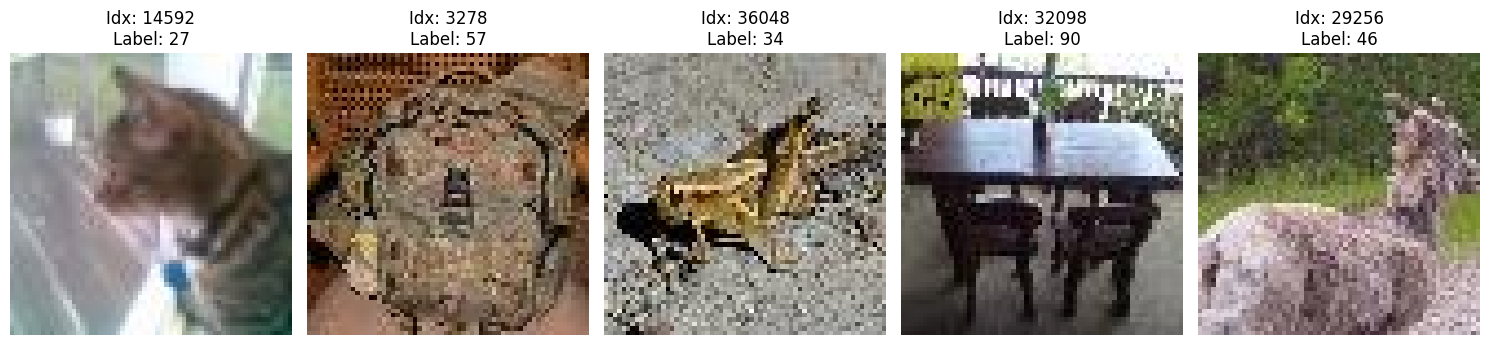

In [4]:
import random

# Set the seed for reproducibility
random.seed(seed)

# 1. Get 5 random indices from the training dataset
# Use train_dataset_transformed to ensure we get preprocessed tensors
random_indices = random.sample(range(len(train_dataset_transformed)), 5)

# 2. Denormalization parameters (matching the transform's mean and std)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# 3. Plot the de-normalized images
plt.figure(figsize=(15, 5))
for i, idx in enumerate(random_indices):
    # This retrieves the preprocessed sample (dict containing 'pixel_values' tensor and 'label')
    sample = train_dataset_transformed[idx]
    img = sample['pixel_values'].cpu()

    # De-normalize the tensor back to the original pixel range [0, 1]
    img = img * std + mean

    # Convert shape from (C, H, W) to (H, W, C) for Matplotlib
    img = img.numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1) # Clip values to keep them in valid [0, 1] range

    label = sample['label']

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Idx: {idx}\nLabel: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## <h2><b>The Architecture</b></h2>

In [5]:
class CNNAutoencoder(nn.Module):
    def __init__(self):
        super(CNNAutoencoder, self).__init__()
        # ====================================
        # THE ENCODER
        # Input shape: [Batch, 3, 64, 64]
        # ====================================

        self.encoder = nn.Sequential(
            # Layer 1: 3 channels -> 16 channels, size halves to 32 x 32
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),

            # Layer 2: 16 channels -> 32 channels, size halves to 16 x 16
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),

            # Layer 3: 32 channels -> 64 channels, size halves to 8 x 8
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),

            # Layer 4: 64 channels -> 128 channels, size halves to 4 x 4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True)
        )
        # now the output representation will be a tensor of 128x4x4

        # ======================================
        # THE DECODER
        # Input shape: [Batch, 128, 4, 4]
        # ======================================

        self.decoder = nn.Sequential(
            # Layer 1: 128 channels -> 64 channels, size doubles to 8 x 8
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),

            # Layer 2: 64 channels -> 32 channel, size doubles to 16 x 16
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),

            # Layer 3: 32 channels -> 16 channels, size doubles to 32 x 32
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),

            # Layer 4: 16 channels -> 3 channels, size doubles to 64 x 64
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),

        )
        # now the output representation will be a tensor of 3x64x64 like the original image

        # Note: Because the images were normalized before passing through the encoder, a linear
        # transformation is enough and there is no need of nn.Sigmoid or tanh activations
    def forward(self, x):
        representation = self.encoder(x)
        reconstruction = self.decoder(representation)
        return reconstruction

    def get_representation(self, x):
        # A handy helper method for your downstream task!
        return self.encoder(x)

## <b>Training the Autoencoder</b>

### <i>Hyperparameter Tuning </i>

In [6]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.5 MB/s eta 0:00:00


In [7]:
import optuna
from torch.utils.data import DataLoader

# 1. Use the transformed datasets and HF's native .select() method
tune_train_ds = train_dataset_transformed.select(range(5000))
tune_val_ds = val_dataset_transformed.select(range(500))

tune_train_loader = DataLoader(tune_train_ds, batch_size=64, shuffle=True)
tune_val_loader = DataLoader(tune_val_ds, batch_size=64, shuffle=False)

def objective(trial):
  model = CNNAutoencoder().to(device)

  # optimizer choices
  optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD"])

  # learning rate choices
  lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)

  # weight decay choices
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-1, log=True)

  # dynamically fetch the chosen optimizer from torch.optim
  optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr, weight_decay=weight_decay)

  # MSE loss
  criterion = nn.MSELoss()

  epochs = 5
  for epoch in range(epochs):
    # training phase
    model.train()
    for batch_idx, data in enumerate(tune_train_loader):
      # --- The Crucial Extraction Step ---
      # If data is a dictionary (HuggingFace standard)
      if isinstance(data, dict):
          images = data['pixel_values'].to(device)
      # If data is a list/tuple (PyTorch standard)
      else:
          images = data[0].to(device)

      optimizer.zero_grad()

      # Forward pass
      reconstruction = model(images)

      # Calculate MSE loss (comparing generated image to original image)
      loss = criterion(reconstruction, images)

      # Backprop
      loss.backward()
      optimizer.step()

    # validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
            for data in tune_val_loader:
                images = data[0].to(device) if isinstance(data, list) else data['pixel_values'].to(device)
                reconstruction = model(images)
                loss = criterion(reconstruction, images)
                val_loss += loss.item() * images.size(0)

    val_loss /= len(tune_val_loader.dataset)

    # Report back to Optuna to allow for Pruning (stopping bad trials early)
    trial.report(val_loss, epoch)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

  # Optuna will try to minimize this returned value
  return val_loss

# --- RUN THE STUDY ---
print("Starting Hyperparameter Tuning...")
study = optuna.create_study(direction="minimize")
# Run for 20 trials to see what works best
study.optimize(objective, n_trials=20)

print(f"Best trial parameters: {study.best_params}")


[I 2026-06-28 11:55:46,452] A new study created in memory with name: no-name-96597bad-b31c-42fe-ab1b-f43d3edf36be


Starting Hyperparameter Tuning...


[I 2026-06-28 11:56:06,111] Trial 0 finished with value: 0.6263178768157959 and parameters: {'optimizer': 'Adam', 'lr': 8.626042922574092e-05, 'weight_decay': 9.066662228015586e-05}. Best is trial 0 with value: 0.6263178768157959.
[I 2026-06-28 11:56:24,109] Trial 1 finished with value: 0.4464865155220032 and parameters: {'optimizer': 'AdamW', 'lr': 0.011166952224960837, 'weight_decay': 0.0012008372566662618}. Best is trial 1 with value: 0.4464865155220032.
[I 2026-06-28 11:56:36,793] Trial 2 finished with value: 0.8564488005638122 and parameters: {'optimizer': 'AdamW', 'lr': 4.2437432205312474e-05, 'weight_decay': 0.0011599383268238962}. Best is trial 1 with value: 0.4464865155220032.
[I 2026-06-28 11:56:49,078] Trial 3 finished with value: 1.4630807733535767 and parameters: {'optimizer': 'SGD', 'lr': 0.00016568807521885197, 'weight_decay': 0.001104809328105325}. Best is trial 1 with value: 0.4464865155220032.
[I 2026-06-28 11:57:01,407] Trial 4 finished with value: 1.3880818395614625

Best trial parameters: {'optimizer': 'AdamW', 'lr': 0.005425953214022643, 'weight_decay': 1.4884242305457286e-05}


### <i>Training</i>

In [8]:
import copy

# 1. Initialization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNAutoencoder().to(device)  # Fixed: Match class name

# --- REPLACE THESE WITH YOUR OPTUNA RESULTS ---
BEST_LR = 0.001
BEST_WEIGHT_DECAY = 1e-4
BEST_OPTIMIZER = optim.AdamW # Or Adam/SGD based on your results
# ----------------------------------------------

optimizer = BEST_OPTIMIZER(model.parameters(), lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY)
criterion = nn.MSELoss()

# 2. Training Configurations
EPOCHS = 50
PATIENCE = 5 # Early stopping patience

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = None

print("Starting Full Training Run...")

for epoch in range(EPOCHS):
    # =========================
    # TRAINING PHASE
    # =========================
    model.train()
    running_train_loss = 0.0

    for batch_idx, data in enumerate(train_loader):
        # Fixed: Safe extraction using 'pixel_values'
        if isinstance(data, dict):
            images = data['pixel_values'].to(device)
        else:
            images = data[0].to(device)

        optimizer.zero_grad()

        reconstruction = model(images)
        loss = criterion(reconstruction, images)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    # =========================
    # VALIDATION PHASE
    # =========================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for data in val_loader:
            # Fixed: Safe extraction using 'pixel_values'
            if isinstance(data, dict):
                images = data['pixel_values'].to(device)
            else:
                images = data[0].to(device)

            reconstruction = model(images)
            loss = criterion(reconstruction, images)
            running_val_loss += loss.item() * images.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

    # =========================
    # EARLY STOPPING & SAVING
    # =========================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())

        # Save model weights to disk
        torch.save(model.state_dict(), 'best_autoencoder.pth')
        print(f"  --> Model improved! Saving weights.")
    else:
        epochs_no_improve += 1
        print(f"  --> No improvement for {epochs_no_improve} epochs.")

        if epochs_no_improve >= PATIENCE:
            print("Early Stopping Triggered! Halting training.")
            break

# 3. Wrap Up
print("Training Complete.")
model.load_state_dict(best_model_weights)
print(f"Loaded best model with Val Loss: {best_val_loss:.6f}")


Starting Full Training Run...
Epoch 1/50 | Train Loss: 0.372059 | Val Loss: 0.251568
  --> Model improved! Saving weights.
Epoch 2/50 | Train Loss: 0.226747 | Val Loss: 0.202694
  --> Model improved! Saving weights.
Epoch 3/50 | Train Loss: 0.192790 | Val Loss: 0.180183
  --> Model improved! Saving weights.
Epoch 4/50 | Train Loss: 0.176967 | Val Loss: 0.171485
  --> Model improved! Saving weights.
Epoch 5/50 | Train Loss: 0.165722 | Val Loss: 0.159779
  --> Model improved! Saving weights.
Epoch 6/50 | Train Loss: 0.159768 | Val Loss: 0.155850
  --> Model improved! Saving weights.
Epoch 7/50 | Train Loss: 0.153916 | Val Loss: 0.147835
  --> Model improved! Saving weights.
Epoch 8/50 | Train Loss: 0.148118 | Val Loss: 0.142873
  --> Model improved! Saving weights.
Epoch 9/50 | Train Loss: 0.143408 | Val Loss: 0.140486
  --> Model improved! Saving weights.
Epoch 10/50 | Train Loss: 0.139229 | Val Loss: 0.137890
  --> Model improved! Saving weights.
Epoch 11/50 | Train Loss: 0.134908 | Va

## <b> Testing and Visualizing</b>

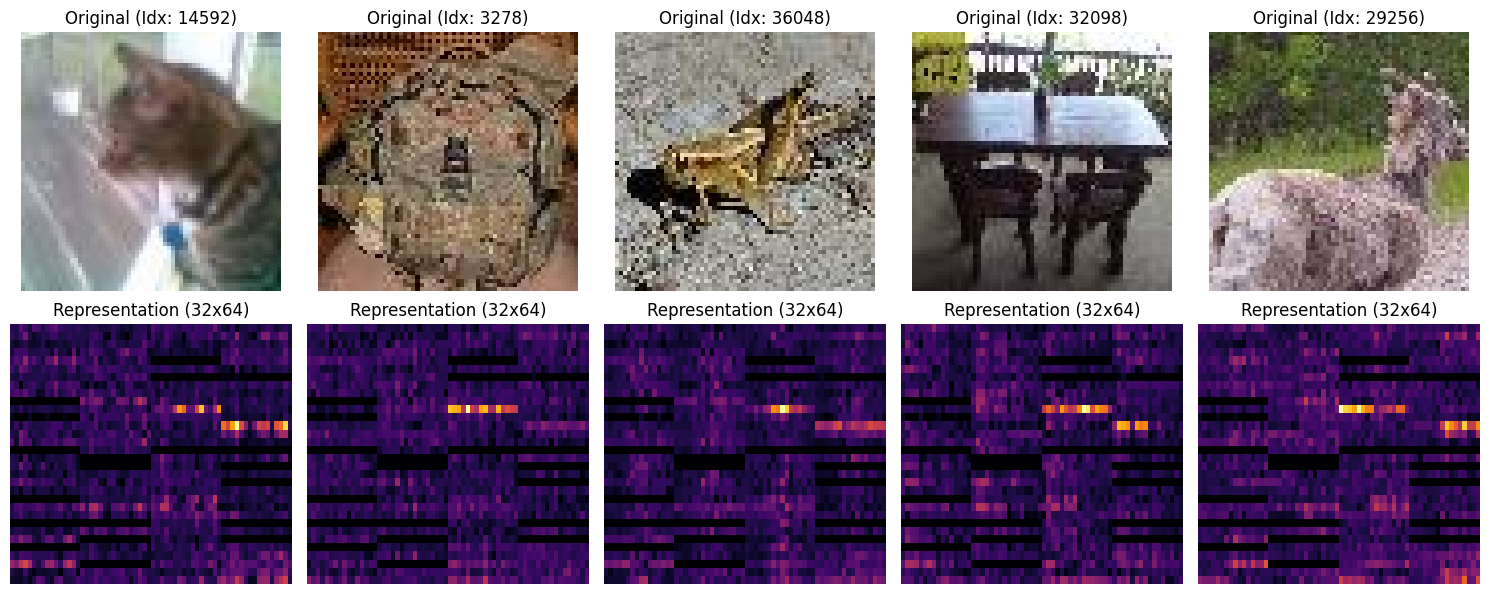

In [9]:
# 1. Set model to evaluation mode
model.eval()

# 2. Setup the plot grid: 2 rows, 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

with torch.no_grad():
    for i, idx in enumerate(random_indices): # Reusing the same indices from the illustration cell
        # --- Row 1: Original Images ---
        # Fetch raw sample for plotting the original image
        sample_raw = train_dataset[idx]
        axes[0, i].imshow(sample_raw['image'])
        axes[0, i].set_title(f"Original (Idx: {idx})")
        axes[0, i].axis('off')

        # --- Get the preprocessed tensor and run through Encoder ---
        # Fetch transformed sample for the model input
        sample_transformed = train_dataset_transformed[idx] # <--- Added this line
        img_tensor = sample_transformed['pixel_values'].unsqueeze(0).to(device) # Shape: [1, 3, 64, 64]

        # Output shape: [1, 128, 4, 4]
        representation = model.get_representation(img_tensor).squeeze(0).cpu() # Shape: [128, 4, 4]

        # --- Row 2: Representations (Reshaped 32x64 Heatmap) ---
        # Flatten the 128x4x4 (2048) representation and reshape to 32x64 for plotting
        flattened_rep = representation.flatten().numpy()
        reshaped_rep = flattened_rep.reshape(32, 64)

        axes[1, i].imshow(reshaped_rep, cmap='inferno', aspect='auto')
        axes[1, i].set_title("Representation (32x64)")
        axes[1, i].axis('off')

plt.tight_layout()
plt.show()


The grid above is a visual representations of the tensor representations. The tensor was flattened and reshaped to 32 x 64 matrix for the visualization.